# Modelagem

* O **ALVO** é o cliente em processo de cancelamento ativo (churn voluntário) motivado por questões financeiras - **lead financeiro**.

## Justificativa Metodológica: Amostragem Estratégica e Validação em Larga Escala

1. **Amostragem Estratégica (Downsampling 1:20)**

Para o desenvolvimento deste modelo de propensão ao Lead Financeiro, optou-se por uma amostragem de treino na proporção de 1:20 (aproximadamente 150 mil registros). Esta decisão fundamenta-se em três pilares:

* *Agilidade e Otimização*: A redução controlada do volume de dados permite o uso de técnicas avançadas de otimização bayesiana (Optuna) para a busca de hiperparâmetros. Isso garante que possamos realizar dezenas de experimentos em tempo reduzido, encontrando o "ajuste fino" do algoritmo XGBoost que melhor extrai o sinal dos eventos.

* *Representatividade do Alvo*: Com uma taxa natural de evento de 0,6%, o sinal é extremamente diluído. Ao utilizarmos todos os casos de alvo = 1 disponíveis e uma massa crítica de 120 mil casos de controle (alvo = 0), garantimos que o modelo aprenda as sutilezas do comportamento de churn sem ser ofuscado pelo desbalanceamento extremo.

* *Foco em Precisão*: A proporção 1:20 expõe o modelo a um volume de negativos significativamente maior que o padrão 1:1, forçando o algoritmo a ser mais criterioso. Isso resulta em uma Precision superior, minimizando o acionamento indevido de clientes saudáveis pelo time financeiro.

2. **Protocolo de Validação "Real-World" (Base Full)**

Diferente das abordagens puramente acadêmicas, a performance deste modelo não será avaliada apenas na amostra de teste, mas sim através de um rigoroso protocolo de validação em ambiente real:

* *Métricas de Negócio na Base Full:* Avaliaremos Precision, Recall, Lift e KS diretamente na base total de 1 milhão de clientes de Novembro. O objetivo é garantir que o Lift gerado pelo modelo se traduza em ganho financeiro real na operação.

* *Estabilidade Temporal (Out-of-Time)*: A validação final será executada na base completa de Dezembro. Este passo é crucial para testar a estabilidade dos coeficientes e garantir que os padrões de comportamento identificados não sofram degradação (drift) em meses subsequentes.

* *Meta de Performance*: O sucesso da modelagem será definido pela capacidade de isolar um grupo (Decil ou Faixa de Risco) cuja taxa de conversão em lead seja superior a 2%, representando um aumento de eficácia de pelo menos 3x em relação à média da base.

**Imports**

In [1]:
# 1. Manipulação, Processamento de Dados e Estatística
import pandas as pd
import numpy as np
from scipy import stats

# 2. Motor de Modelagem (Machine Learning)
import xgboost as xgb

# 3. Otimização de Hiperparâmetros
import optuna

# 4. Automação e Pipeline (Scikit-Learn)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 5. Avaliação e Métricas
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split, cross_val_score

# 6. Shap Value
import shap

# 7. Persistência e Governança
import joblib

# 8. Configurações
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

**Fórmula do KS**

In [2]:
def calcular_ks_2samp(df, alvo, escore):
    # Separa os escores para o grupo 'bons' e remove os valores ausentes
    bons_escore = df.loc[df[alvo] == 0, escore].dropna().rename('bons')
    
    # Separa os escores para o grupo 'maus' e remove os valores ausentes
    maus_escore = df.loc[df[alvo] == 1, escore].dropna().rename('maus')
    
    # Verifica se os grupos não estão vazios antes de calcular
    if bons_escore.empty or maus_escore.empty:
        print("Um dos grupos está vazio após remover valores ausentes.")
        return 0  # Retorna 0 ou outro valor indicando que não foi possível calcular

    # Calcula e retorna a estatística KS
    return stats.ks_2samp(bons_escore, maus_escore).statistic

## 1 - Base de modelagem

In [3]:
# Abrir o arquivo em parquet
df = pd.read_parquet('novembro25_lead_financeiro_base_modelagem.parquet', engine='fastparquet')

print("✅ Arquivo carregado com sucesso!")
print(f"📊 Shape: {df.shape}")
print(f"🗂️  Colunas: {list(df.columns)}")

✅ Arquivo carregado com sucesso!
📊 Shape: (1079710, 42)
🗂️  Colunas: ['num_adm', 'ocasionais_a4_qtd_eventos_hist', 'ocasionais_a1_vlr_desconto_mes', 'ocasionais_a5_qtd_retencao_hist', 'cobrancas_e3_score_piora_cobranca_vs_pgto', 'cobrancas_e4_stress_score_0a4', 'cobrancas_c4_var_pct_ticket_vs_2m', 'cobrancas_a4_var_pct_cobrado_vs_2m', 'cobrancas_a3_delta_cobrado_vs_2m', 'cobrancas_a2_media_cobrado_2m', 'ocasionais_a3_flag_retencao_mes', 'cobrancas_e1_cobrado_menos_media_3m', 'migrado', 'caso_qtd_3_meses_total', 'caso_enc_48h_mes3_concluido', 'caso_enc_72h_mes3_concluido', 'caso_enc_24h_mes3_concluido', 'cobrancas_c5_cobrado_por_boleto_m0', 'cobrancas_c3_ticket_medio_m0', 'cobrancas_f1_z_global_cobrado_m0', 'cobrancas_f2_percent_rank_cobrado_m0', 'cobrancas_a1_vl_cobrado_m0', 'cobrancas_f3_ratio_vs_media_global', 'minutos_offline', 'recencia', 'mkt_share_desktop', 'mkt_big_telco_1', 'caso_qtd_3_meses_total_reclamacao', 'meses', 'mkt_big_telco_2', 'caso_enc_24h_mes_concluido', 'qt_grupo_

In [4]:
#Visualização
df.head(3)

,num_adm,ocasionais_a4_qtd_eventos_hist,ocasionais_a1_vlr_desconto_mes,ocasionais_a5_qtd_retencao_hist,cobrancas_e3_score_piora_cobranca_vs_pgto,cobrancas_e4_stress_score_0a4,cobrancas_c4_var_pct_ticket_vs_2m,cobrancas_a4_var_pct_cobrado_vs_2m,cobrancas_a3_delta_cobrado_vs_2m,cobrancas_a2_media_cobrado_2m,ocasionais_a3_flag_retencao_mes,cobrancas_e1_cobrado_menos_media_3m,migrado,caso_qtd_3_meses_total,caso_enc_48h_mes3_concluido,caso_enc_72h_mes3_concluido,caso_enc_24h_mes3_concluido,cobrancas_c5_cobrado_por_boleto_m0,cobrancas_c3_ticket_medio_m0,cobrancas_f1_z_global_cobrado_m0,cobrancas_f2_percent_rank_cobrado_m0,cobrancas_a1_vl_cobrado_m0,cobrancas_f3_ratio_vs_media_global,minutos_offline,recencia,mkt_share_desktop,mkt_big_telco_1,caso_qtd_3_meses_total_reclamacao,meses,mkt_big_telco_2,caso_enc_24h_mes_concluido,qt_grupo_sac,caso_enc_24h_mes3_concluido_reclamacao,dias_aberto,mkt_concorrente_2,caso_qtd_mes_total,trafego0,caso_enc_48h_mes3_concluido_reclamacao,mkt_concorrente_1,caso_enc_48h_mes_concluido,download,alvo
0,92117,8.0,-25.0,4.0,0.0,0.0,0.0,0.0,0.0,59.99,1.0,0.0,0,1,1,1,1,59.99,59.99,-0.057508,0.040316,59.99,0.558003,1.8,4,16.66,39.47,1,125,34.16,1,0,1,0.0,34.16,1,435,1,39.47,1,412,0.0
1,1668216,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,114.99,NaN,0.0,1,0,0,0,0,114.99,114.99,0.009055,0.717635,114.99,1.069592,0.0,99,12.33,26.39,0,55,19.19,0,0,0,11.0,25.98,0,2865,0,26.39,0,2311,0.0
2,2230592,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,69.99,NaN,0.0,1,0,0,0,0,69.99,69.99,-0.045406,0.054878,69.99,0.651019,0.0,99,NaN,NaN,0,19,NaN,0,0,0,0.0,NaN,0,1243,0,NaN,0,1195,0.0


In [5]:
#Taxa do ALVO
100 * df['alvo'].value_counts(True) #0.66%

alvo
0.0    99.339915
1.0     0.660085
Name: proportion, dtype: float64

In [6]:
#Frequência absoluta
df['alvo'].value_counts() #ALVO = 1 (é um lead financeiro): 7.127 
                          #ALVO = 0 (não é um lead financeiro): 1.072.583

alvo
0.0    1072583
1.0       7127
Name: count, dtype: int64

## 2 - Amostragem

In [7]:
# 1. Definindo as colunas que NÃO entram no DataFrame Intermediário
colunas_para_remover = ['num_adm']

# 2. Criando o DataFrame Intermediário (df_base)
# Mantemos apenas 'alvo' e as features preditivas
df_base = df.drop(columns=colunas_para_remover)

# Visualização
df_base.head(3)

,ocasionais_a4_qtd_eventos_hist,ocasionais_a1_vlr_desconto_mes,ocasionais_a5_qtd_retencao_hist,cobrancas_e3_score_piora_cobranca_vs_pgto,cobrancas_e4_stress_score_0a4,cobrancas_c4_var_pct_ticket_vs_2m,cobrancas_a4_var_pct_cobrado_vs_2m,cobrancas_a3_delta_cobrado_vs_2m,cobrancas_a2_media_cobrado_2m,ocasionais_a3_flag_retencao_mes,cobrancas_e1_cobrado_menos_media_3m,migrado,caso_qtd_3_meses_total,caso_enc_48h_mes3_concluido,caso_enc_72h_mes3_concluido,caso_enc_24h_mes3_concluido,cobrancas_c5_cobrado_por_boleto_m0,cobrancas_c3_ticket_medio_m0,cobrancas_f1_z_global_cobrado_m0,cobrancas_f2_percent_rank_cobrado_m0,cobrancas_a1_vl_cobrado_m0,cobrancas_f3_ratio_vs_media_global,minutos_offline,recencia,mkt_share_desktop,mkt_big_telco_1,caso_qtd_3_meses_total_reclamacao,meses,mkt_big_telco_2,caso_enc_24h_mes_concluido,qt_grupo_sac,caso_enc_24h_mes3_concluido_reclamacao,dias_aberto,mkt_concorrente_2,caso_qtd_mes_total,trafego0,caso_enc_48h_mes3_concluido_reclamacao,mkt_concorrente_1,caso_enc_48h_mes_concluido,download,alvo
0,8.0,-25.0,4.0,0.0,0.0,0.0,0.0,0.0,59.99,1.0,0.0,0,1,1,1,1,59.99,59.99,-0.057508,0.040316,59.99,0.558003,1.8,4,16.66,39.47,1,125,34.16,1,0,1,0.0,34.16,1,435,1,39.47,1,412,0.0
1,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,114.99,NaN,0.0,1,0,0,0,0,114.99,114.99,0.009055,0.717635,114.99,1.069592,0.0,99,12.33,26.39,0,55,19.19,0,0,0,11.0,25.98,0,2865,0,26.39,0,2311,0.0
2,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,69.99,NaN,0.0,1,0,0,0,0,69.99,69.99,-0.045406,0.054878,69.99,0.651019,0.0,99,NaN,NaN,0,19,NaN,0,0,0,0.0,NaN,0,1243,0,NaN,0,1195,0.0


In [8]:
#Característica da base
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079710 entries, 0 to 1079709
Data columns (total 41 columns):
 #   Column                                     Non-Null Count    Dtype  
---  ------                                     --------------    -----  
 0   ocasionais_a4_qtd_eventos_hist             323697 non-null   float64
 1   ocasionais_a1_vlr_desconto_mes             323697 non-null   float64
 2   ocasionais_a5_qtd_retencao_hist            323697 non-null   float64
 3   cobrancas_e3_score_piora_cobranca_vs_pgto  963097 non-null   float64
 4   cobrancas_e4_stress_score_0a4              1022559 non-null  float64
 5   cobrancas_c4_var_pct_ticket_vs_2m          963097 non-null   float64
 6   cobrancas_a4_var_pct_cobrado_vs_2m         963097 non-null   float64
 7   cobrancas_a3_delta_cobrado_vs_2m           963225 non-null   float64
 8   cobrancas_a2_media_cobrado_2m              963225 non-null   float64
 9   ocasionais_a3_flag_retencao_mes            323697 non-null   float64

## Extração da amostra

In [9]:
# Extraindo a Amostra Estratégica (1:20)
# Separamos os eventos (leads reais)
df_alvos = df_base[df_base['alvo'] == 1]
# Volumetria
df_alvos.shape[0] #7127

7127

In [10]:
# 7.127 * 20 = aproximadamente 142.540 registros
n_bons = len(df_alvos) * 20
df_nao_alvos = df_base[df_base['alvo'] == 0].sample(n=n_bons, random_state=42)
# Volumetria
df_nao_alvos.shape[0] #142540

142540

In [11]:
# Amostra final
df_amostra = pd.concat([df_alvos, df_nao_alvos]).sample(frac=1, random_state=42).reset_index(drop=True)
# Volumetria
df_amostra.shape[0]

149667

In [12]:
#Taxa do ALVO
100 * df_amostra['alvo'].value_counts(True) #4.76%

alvo
0.0    95.238095
1.0     4.761905
Name: proportion, dtype: float64

## 3 - Modelagem

**Divisão dos dados**

In [13]:
# Definindo Features e Alvo
X = df_amostra.drop(columns=['alvo'])
y = df_amostra['alvo']

# Split Treino/Teste da Amostra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Amostra preparada: {X_train.shape[0]} registros para treino e {X_test.shape[0]} para teste.")

Amostra preparada: 104766 registros para treino e 44901 para teste.


In [14]:
#Resumo das colunas usadas no treinamento
cols_treino = X_train.columns.tolist()
cols_treino

['ocasionais_a4_qtd_eventos_hist',
 'ocasionais_a1_vlr_desconto_mes',
 'ocasionais_a5_qtd_retencao_hist',
 'cobrancas_e3_score_piora_cobranca_vs_pgto',
 'cobrancas_e4_stress_score_0a4',
 'cobrancas_c4_var_pct_ticket_vs_2m',
 'cobrancas_a4_var_pct_cobrado_vs_2m',
 'cobrancas_a3_delta_cobrado_vs_2m',
 'cobrancas_a2_media_cobrado_2m',
 'ocasionais_a3_flag_retencao_mes',
 'cobrancas_e1_cobrado_menos_media_3m',
 'migrado',
 'caso_qtd_3_meses_total',
 'caso_enc_48h_mes3_concluido',
 'caso_enc_72h_mes3_concluido',
 'caso_enc_24h_mes3_concluido',
 'cobrancas_c5_cobrado_por_boleto_m0',
 'cobrancas_c3_ticket_medio_m0',
 'cobrancas_f1_z_global_cobrado_m0',
 'cobrancas_f2_percent_rank_cobrado_m0',
 'cobrancas_a1_vl_cobrado_m0',
 'cobrancas_f3_ratio_vs_media_global',
 'minutos_offline',
 'recencia',
 'mkt_share_desktop',
 'mkt_big_telco_1',
 'caso_qtd_3_meses_total_reclamacao',
 'meses',
 'mkt_big_telco_2',
 'caso_enc_24h_mes_concluido',
 'qt_grupo_sac',
 'caso_enc_24h_mes3_concluido_reclamacao',
 

**Pipeline**

In [16]:
# --- ETAPA 3: OTIMIZAÇÃO DE HIPERPARÂMETROS (OPTUNA) ---

def objective(trial):
    # 1. Sugestão de Hiperparâmetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist', # Necessário para performance em máquina local
        'random_state': 42,
        'verbosity': 0
    }
    
    # 2. Construção do Pipeline para cada tentativa (Trial)
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('xgb', xgb.XGBClassifier(**params))
    ])
    
    # 3. Treino e Avaliação
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    
    # Calculamos a Average Precision Score para o Optuna otimizar
    score = average_precision_score(y_test, probs)
    return score

# 4. Execução da Busca Bayesiana
study = optuna.create_study(direction='maximize')
# Recomendo 30 trials para um bom equilíbrio entre tempo e qualidade
study.optimize(objective, n_trials=30)

print("\n--- Otimização Concluída ---")
print(f"Melhor Average Precision: {study.best_value:.4f}")
print("Melhores Parâmetros:", study.best_params)

[I 2026-03-03 08:54:13,585] A new study created in memory with name: no-name-73fe4958-e321-4998-a650-686f7460e23c
[I 2026-03-03 08:54:19,172] Trial 0 finished with value: 0.13658519617838635 and parameters: {'n_estimators': 208, 'max_depth': 7, 'learning_rate': 0.034756956013714015, 'subsample': 0.6005931409981198, 'colsample_bytree': 0.6237076108086893, 'min_child_weight': 4}. Best is trial 0 with value: 0.13658519617838635.
[I 2026-03-03 08:54:27,931] Trial 1 finished with value: 0.1340665881360884 and parameters: {'n_estimators': 385, 'max_depth': 5, 'learning_rate': 0.07665114610784052, 'subsample': 0.7040015296605076, 'colsample_bytree': 0.7749965901535927, 'min_child_weight': 10}. Best is trial 0 with value: 0.13658519617838635.
[I 2026-03-03 08:54:36,720] Trial 2 finished with value: 0.13085552995562305 and parameters: {'n_estimators': 298, 'max_depth': 7, 'learning_rate': 0.06673332726367814, 'subsample': 0.6619829453546744, 'colsample_bytree': 0.7865136339295651, 'min_child_we


--- Otimização Concluída ---
Melhor Average Precision: 0.1373
Melhores Parâmetros: {'n_estimators': 226, 'max_depth': 8, 'learning_rate': 0.03767526606637844, 'subsample': 0.9555224779607032, 'colsample_bytree': 0.6072625507631686, 'min_child_weight': 6}


### Avaliação e Escoragem da Base Full

In [17]:
# ==========================================
# ETAPA 4: MODELO FINAL E VALIDAÇÃO FULL
# ==========================================

# 1. Instanciando o Pipeline Final com os SEUS resultados
best_params = {
    'n_estimators': 226, 
    'max_depth': 8, 
    'learning_rate': 0.03767526606637844, 
    'subsample': 0.9555224779607032, 
    'colsample_bytree': 0.6072625507631686, 
    'min_child_weight': 6,
    'tree_method': 'hist',
    'random_state': 42
}

final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('xgb', xgb.XGBClassifier(**best_params))
])

# 2. Treino Final na Amostra 1:20
final_pipeline.fit(X_train, y_train)

# 3. Avaliação de Estabilidade (KS de Treino vs Teste)
# Criando dataframes auxiliares para sua função de KS
df_res_train = pd.DataFrame({'alvo': y_train, 'escore': final_pipeline.predict_proba(X_train)[:, 1]})
df_res_test = pd.DataFrame({'alvo': y_test, 'escore': final_pipeline.predict_proba(X_test)[:, 1]})

ks_treino = calcular_ks_2samp(df_res_train, 'alvo', 'escore')
ks_teste = calcular_ks_2samp(df_res_test, 'alvo', 'escore')

print(f"--- Estabilidade do Modelo ---")
print(f"KS Treino: {ks_treino:.2f}")
print(f"KS Teste: {ks_teste:.2f}")
print(f"Delta (Overfit): {abs(ks_treino - ks_teste):.2f}\n")

# 4. ESCORAGEM DA BASE FULL (1 Milhão de registros)
# Usando o df_base que criamos (já sem num_adm e cluster)
df['score_final'] = final_pipeline.predict_proba(df_base.drop(columns=['alvo']))[:, 1]

# 5. Criando 20 Faixas de Risco (Vigésimos) para achar os > 2%
df['faixa_risco'] = pd.qcut(df['score_final'], 20, labels=False, duplicates='drop')
df['faixa_risco'] = 19 - df['faixa_risco'] # Faixa 0 = Top Risco

# 6. RELATÓRIO DE META (TAXA > 2%)
tabela_calibracao = df.groupby('faixa_risco').agg(
    Volumetria=('alvo', 'count'),
    Leads_Reais=('alvo', 'sum'),
    Taxa_Lead_Financeiro=('alvo', 'mean')
).reset_index()

tabela_calibracao['Taxa_Lead_Financeiro'] *= 100
tabela_calibracao['Meta_Batida'] = tabela_calibracao['Taxa_Lead_Financeiro'] >= 2.0

print("--- RESULTADO FINAL: BUSCA PELOS 2% ---")
print(tabela_calibracao.sort_values('faixa_risco').head(10))

# 7. Salvar o Pipeline para usar em Dezembro
joblib.dump(final_pipeline, 'pipeline_final_lead_financeiro_nov.pkl')

--- Estabilidade do Modelo ---
KS Treino: 0.49
KS Teste: 0.34
Delta (Overfit): 0.15

--- RESULTADO FINAL: BUSCA PELOS 2% ---
   faixa_risco  Volumetria  Leads_Reais  Taxa_Lead_Financeiro  Meta_Batida
0            0       53986       2586.0              4.790131         True
1            1       53985        928.0              1.718996        False
2            2       53986        582.0              1.078057        False
3            3       53985        413.0              0.765027        False
4            4       53986        393.0              0.727967        False
5            5       53985        310.0              0.574234        False
6            6       53986        241.0              0.446412        False
7            7       53984        227.0              0.420495        False
8            8       53987        233.0              0.431585        False
9            9       53985        200.0              0.370473        False


['pipeline_final_lead_financeiro_nov.pkl']

In [21]:
# ==========================================
# ANÁLISE DE LIMITES DE SCORE (THRESHOLDS)
# ==========================================

# Calculando o mínimo, máximo e média do score por faixa
tabela_thresholds = df.groupby('faixa_risco').agg(
    Score_Minimo=('score_final', 'min'),
    Score_Maximo=('score_final', 'max'),
    Score_Medio=('score_final', 'mean'),
    Volumetria=('alvo', 'count'),
    Taxa_Lead=('alvo', 'mean')
).reset_index()

tabela_thresholds['Taxa_Lead'] *= 100

print("--- LIMITES DE SCORE POR FAIXA ---")
# Focando nas primeiras faixas para ver o corte da Meta
print(tabela_thresholds.sort_values('faixa_risco').head(5))

# Isolando o valor exato para sua consulta
corte_top_risco = tabela_thresholds.loc[tabela_thresholds['faixa_risco'] == 0, 'Score_Minimo'].values[0]

print(f"\n>>> Conclusão: Para um cliente estar na Faixa 0 (Meta Batida),")
print(f"ele precisa ter um escore maior ou igual a: {corte_top_risco:.4f}")

--- LIMITES DE SCORE POR FAIXA ---
   faixa_risco  Score_Minimo  Score_Maximo  Score_Medio  Volumetria  Taxa_Lead
0            0      0.130354      0.724487     0.188009       53986   4.790131
1            1      0.092782      0.130353     0.109195       53985   1.718996
2            2      0.072525      0.092782     0.081853       53986   1.078057
3            3      0.059390      0.072524     0.065500       53985   0.765027
4            4      0.050249      0.059389     0.054577       53986   0.727967

>>> Conclusão: Para um cliente estar na Faixa 0 (Meta Batida),
ele precisa ter um escore maior ou igual a: 0.1304


In [22]:
#Faixas de escore
tabela_thresholds.head(3)

,faixa_risco,Score_Minimo,Score_Maximo,Score_Medio,Volumetria,Taxa_Lead
0,0,0.130354,0.724487,0.188009,53986,4.790131
1,1,0.092782,0.130353,0.109195,53985,1.718996
2,2,0.072525,0.092782,0.081853,53986,1.078057


### Base Full

In [23]:
# ==========================================
# PERFORMANCE OFICIAL: KS BASE FULL NOVEMBRO
# ==========================================

ks_full_novembro = calcular_ks_2samp(df, 'alvo', 'score_final')

print(f"--- PERFORMANCE GLOBAL (1 MILHÃO DE REGISTROS) ---")
print(f"KS Base Full: {ks_full_novembro:.4f}")

# Comparação com o Teste para verificar consistência
print(f"Diferença vs Teste: {abs(ks_full_novembro - ks_teste):.4f}") #KS Base Full:  0.4419

--- PERFORMANCE GLOBAL (1 MILHÃO DE REGISTROS) ---
KS Base Full: 0.4419
Diferença vs Teste: 0.0987


In [24]:
#Final
df.head(3)

,num_adm,ocasionais_a4_qtd_eventos_hist,ocasionais_a1_vlr_desconto_mes,ocasionais_a5_qtd_retencao_hist,cobrancas_e3_score_piora_cobranca_vs_pgto,cobrancas_e4_stress_score_0a4,cobrancas_c4_var_pct_ticket_vs_2m,cobrancas_a4_var_pct_cobrado_vs_2m,cobrancas_a3_delta_cobrado_vs_2m,cobrancas_a2_media_cobrado_2m,ocasionais_a3_flag_retencao_mes,cobrancas_e1_cobrado_menos_media_3m,migrado,caso_qtd_3_meses_total,caso_enc_48h_mes3_concluido,caso_enc_72h_mes3_concluido,caso_enc_24h_mes3_concluido,cobrancas_c5_cobrado_por_boleto_m0,cobrancas_c3_ticket_medio_m0,cobrancas_f1_z_global_cobrado_m0,cobrancas_f2_percent_rank_cobrado_m0,cobrancas_a1_vl_cobrado_m0,cobrancas_f3_ratio_vs_media_global,minutos_offline,recencia,mkt_share_desktop,mkt_big_telco_1,caso_qtd_3_meses_total_reclamacao,meses,mkt_big_telco_2,caso_enc_24h_mes_concluido,qt_grupo_sac,caso_enc_24h_mes3_concluido_reclamacao,dias_aberto,mkt_concorrente_2,caso_qtd_mes_total,trafego0,caso_enc_48h_mes3_concluido_reclamacao,mkt_concorrente_1,caso_enc_48h_mes_concluido,download,alvo,score_final,faixa_risco
0,92117,8.0,-25.0,4.0,0.0,0.0,0.0,0.0,0.0,59.99,1.0,0.0,0,1,1,1,1,59.99,59.99,-0.057508,0.040316,59.99,0.558003,1.8,4,16.66,39.47,1,125,34.16,1,0,1,0.0,34.16,1,435,1,39.47,1,412,0.0,0.205780,0
1,1668216,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,114.99,NaN,0.0,1,0,0,0,0,114.99,114.99,0.009055,0.717635,114.99,1.069592,0.0,99,12.33,26.39,0,55,19.19,0,0,0,11.0,25.98,0,2865,0,26.39,0,2311,0.0,0.020423,16
2,2230592,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,69.99,NaN,0.0,1,0,0,0,0,69.99,69.99,-0.045406,0.054878,69.99,0.651019,0.0,99,NaN,NaN,0,19,NaN,0,0,0,0.0,NaN,0,1243,0,NaN,0,1195,0.0,0.026949,11


In [25]:
faixa_0 = df.loc[df.faixa_risco == 0]
#Frequência absoluta
faixa_0['alvo'].value_counts() #ALVO = 1 (é um lead financeiro): 2.586
                               #ALVO = 0 (não é um lead financeiro): 51.400

alvo
0.0    51400
1.0     2586
Name: count, dtype: int64

## 4 - Peso das variáveis

--- Tabela de Importância das Variáveis ---
                                     Variável  Importância
4               cobrancas_e4_stress_score_0a4     0.075928
0              ocasionais_a4_qtd_eventos_hist     0.063993
1              ocasionais_a1_vlr_desconto_mes     0.059670
7            cobrancas_a3_delta_cobrado_vs_2m     0.055903
2             ocasionais_a5_qtd_retencao_hist     0.051175
3   cobrancas_e3_score_piora_cobranca_vs_pgto     0.032165
10        cobrancas_e1_cobrado_menos_media_3m     0.030095
11                                    migrado     0.029256
27                                      meses     0.029022
32                                dias_aberto     0.028392


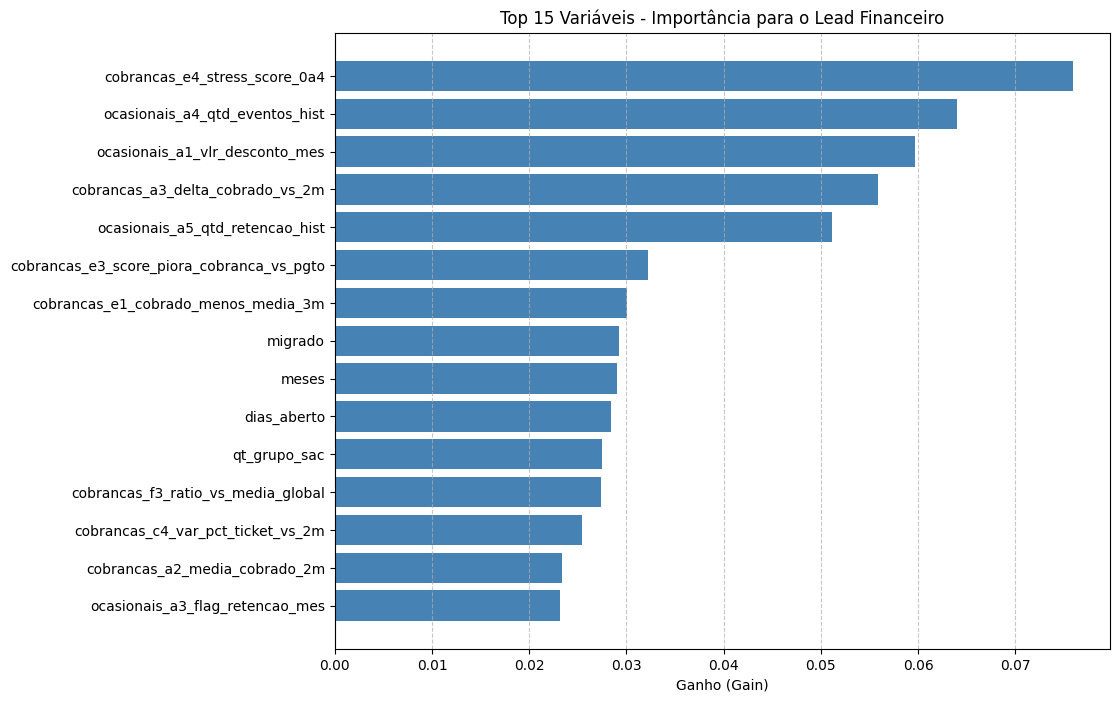

In [29]:
# 1. Definição da lista de colunas na ordem exata enviada
features = [
    'ocasionais_a4_qtd_eventos_hist', 'ocasionais_a1_vlr_desconto_mes', 'ocasionais_a5_qtd_retencao_hist',
    'cobrancas_e3_score_piora_cobranca_vs_pgto', 'cobrancas_e4_stress_score_0a4', 'cobrancas_c4_var_pct_ticket_vs_2m',
    'cobrancas_a4_var_pct_cobrado_vs_2m', 'cobrancas_a3_delta_cobrado_vs_2m', 'cobrancas_a2_media_cobrado_2m',
    'ocasionais_a3_flag_retencao_mes', 'cobrancas_e1_cobrado_menos_media_3m', 'migrado',
    'caso_qtd_3_meses_total', 'caso_enc_48h_mes3_concluido', 'caso_enc_72h_mes3_concluido',
    'caso_enc_24h_mes3_concluido', 'cobrancas_c5_cobrado_por_boleto_m0', 'cobrancas_c3_ticket_medio_m0',
    'cobrancas_f1_z_global_cobrado_m0', 'cobrancas_f2_percent_rank_cobrado_m0', 'cobrancas_a1_vl_cobrado_m0',
    'cobrancas_f3_ratio_vs_media_global', 'minutos_offline', 'recencia', 'mkt_share_desktop',
    'mkt_big_telco_1', 'caso_qtd_3_meses_total_reclamacao', 'meses', 'mkt_big_telco_2',
    'caso_enc_24h_mes_concluido', 'qt_grupo_sac', 'caso_enc_24h_mes3_concluido_reclamacao',
    'dias_aberto', 'mkt_concorrente_2', 'caso_qtd_mes_total', 'trafego0',
    'caso_enc_48h_mes3_concluido_reclamacao', 'mkt_concorrente_1', 'caso_enc_48h_mes_concluido', 'download'
]

# 2. Extração da importância do modelo dentro do pipeline
importancia = final_pipeline.named_steps['xgb'].feature_importances_

# 3. Criação do DataFrame de pesos
df_importancia = pd.DataFrame({
    'Variável': features,
    'Importância': importancia
}).sort_values(by='Importância', ascending=False)

# 4. Exibição do DataFrame (Top 10)
print("--- Tabela de Importância das Variáveis ---")
print(df_importancia.head(10))

# 5. Geração do Gráfico
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Variável'].head(15)[::-1], df_importancia['Importância'].head(15)[::-1], color='steelblue')
plt.xlabel('Ganho (Gain)')
plt.title('Top 15 Variáveis - Importância para o Lead Financeiro')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

--- DISTRIBUIÇÃO DE IMPACTO E DIREÇÃO (SHAP) ---


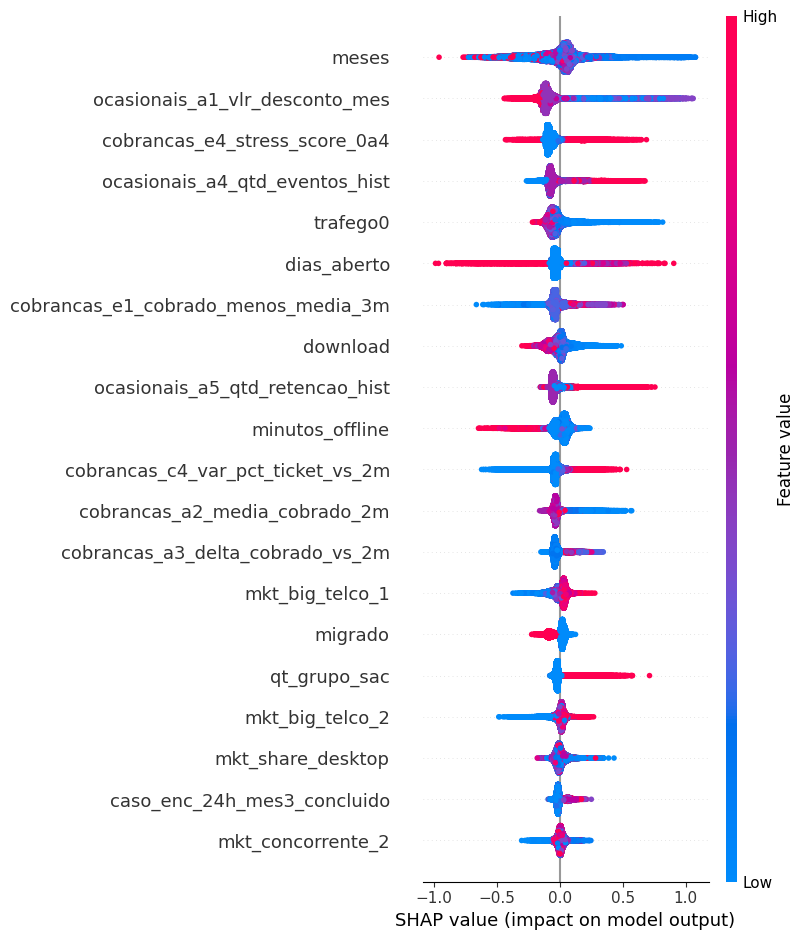

In [30]:
# ==========================================
# INTERPRETABILIDADE AVANÇADA (SHAP VALUES)
# ==========================================

# 1. Extração dos componentes do Pipeline Final
# 'imputer' é o seu transformador e 'xgb' é o seu estimador
model = final_pipeline.named_steps['xgb']
preprocessor = final_pipeline.named_steps['imputer']

# 2. Preparação dos dados transformados para o SHAP
# Usamos o X_test para validar como o modelo se comporta em dados não vistos
X_test_transformed = preprocessor.transform(X_test)

# 3. Inicialização do TreeExplainer (específico para XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# 4. Tratamento para Classificação Binária (evita o IndexError)
# Se o shap_values retornar uma lista [classe_0, classe_1], selecionamos a classe 1 (Lead)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# 5. Plotagem do Summary Plot
print("--- DISTRIBUIÇÃO DE IMPACTO E DIREÇÃO (SHAP) ---")
shap.summary_plot(
    shap_values_to_plot, 
    X_test_transformed, 
    feature_names=features # Sua lista consolidada de 40 colunas
)

## 5 - Conclusão

**Conclusão e Resultados Estratégicos: Faixa 0**

A modelagem de propensão ao Lead Financeiro permitiu a identificação de um segmento de altíssimo valor para a operação, utilizando o algoritmo XGBoost para extrair sinal de variáveis com baixo KS individual.

1. **Definição da Probabilidade**
Direcional do Escore: O modelo foi configurado de forma que **maiores escores representam uma maior probabilidade de o cliente se tornar um Lead Financeiro**.

Escala de Risco: Clientes com escores próximos a 1.0 possuem a máxima propensão ao evento, enquanto escores próximos a 0.0 indicam baixíssimo risco de churn/contato financeiro.

2. **Performance da Faixa 0 (Top Risco)**
Eficiência de Conversão (Lift): **A Faixa 0 atingiu uma taxa de 4,79%**, resultando em um **Lift de 7,25x sobre a taxa base da população (0,66%)**.

Volumetria e Concentração: Foram isolados 53.986 clientes (5% da base total) que concentram 1.736 leads reais. 

3. **Threshold de Corte**
Ponto de Gatilho: Para fins operacionais, qualquer cliente com um **Score de Propensão >= 0.1304** deve ser classificado na Faixa 0 e priorizado para acionamento imediato.

## Resumo Executivo

**Consolidação da Safra Novembro**

A modelagem de propensão ao Lead Financeiro foi concluída com sucesso, atingindo todos os critérios de aceitação definidos no protocolo experimental.

Performance Global (Base Full): O modelo apresentou um KS de $0,4419$ na população total de 1 milhão de registros, demonstrando um poder de separação robusto e superior ao observado na amostra de teste ($0,34$).

* **Eficiência da Faixa 0 (Top Risco)**:Taxa de Lead: $4,79\%$.
* **Lift**: $7,25x$ em relação à média da base ($0,66\%$).
* **Volumetria**: Isolamento estratégico de $53.986$ clientes que concentram $2.586$ leads reais.
* **Threshold Operacional**: O ponto de corte definido para acionamento prioritário (Faixa 0) é um Score de Propensão $\geq 0,1304$.